In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# 1. Lectura de datos
datos = pd.read_csv("datos_mw_conv_final_ohe.csv")
df = datos.copy() # as.data.frame no es estrictamente necesario, pandas ya usa DataFrames

# 2. Suavizar con logaritmo la energía
# np.log1p(x) es el equivalente exacto y optimizado matemáticamente para log(x + 1)
cols_log = [
    'energia_acumulada_diaria', 'energia_lag1', 
    'roll7_energia', 'roll30_energia', 'adj_roll30_energia'
]
df[cols_log] = np.log1p(df[cols_log])

# 3. Estandarización de las variables numéricas
listconti = [
    "eq_count", "energia_acumulada_diaria", "main_mag", "main_depth", "main_lat", 
    "main_lon", "magError", "depthError", "horizontalError", "nst", "gap", "dmin", 
    "rms", "magNst", "is_converted_mag", "lat_bin", "lon_bin", "b_value_daily", 
    "lag1_mag_max", "lag1_eq_count", "energia_lag1", "roll7_eq_count", "roll30_eq_count", 
    "roll7_mag_max", "roll30_mag_max", "roll7_energia", "roll30_energia", 
    "days_since_last_eq", "TARGET_mag_max_next_7d", "lat", "lon", "adj_num_eqs_x", 
    "adj_max_mag_x", "adj_num_eqs_y", "adj_max_mag_y", "adj_roll7_eq_count", 
    "adj_roll7_mag_max", "adj_roll30_energia", "adj_roll30_eq_count", "adj_roll30_mag_max"
]

scaler = StandardScaler()
df[listconti] = scaler.fit_transform(df[listconti])

# 4. Convertir lógicas a numéricas
bool_cols = df.select_dtypes(include=['bool']).columns
df[bool_cols] = df[bool_cols].astype(int)


# Asegurar que la columna 'date' es de tipo datetime para permitir cortes temporales
df['date'] = pd.to_datetime(df['date'])
print(df['date'].dtype)

# 5. División en train y test por corte de tiempo
train = df[df['date'] < "2019-01-01"].copy()
test  = df[df['date'] >= "2019-01-01"].copy()


# 6. Target encoding con ventana móvil
# Creamos una función para evitar repetir el código 4 veces.
def apply_rolling_target_encoding(data, target_col, new_col_name):
    """
    Replica el comportamiento de slide_index_dbl(..., .before=days(30), .after=-1)
    """
    # Guardar la media global para el llenado de NAs
    global_mean = data[target_col].mean()
    
    # 1. Ordenar explícitamente es necesario para funciones rolling indexadas
    data = data.sort_values(by=['cell_id', 'date'])
    
    # 2. Configurar la fecha como índice temporal para que funcione el '30D'
    data_idx = data.set_index('date')
    
    # 3. Agrupar y aplicar la ventana móvil.
    # closed='left' es la clave: calcula usando datos hasta el día de ayer, excluyendo hoy (-1)
    rolling_means = (
        data_idx.groupby('cell_id')[target_col]
        .rolling('30D', closed='left')
        .mean()
    )
    
    # 4. Extraer los valores calculados a la columna nueva
    data[new_col_name] = rolling_means.values
    
    # 5. Rellenar NAs iniciales con la media global
    data[new_col_name] = data[new_col_name].fillna(global_mean)
    
    return data

# Aplicación en los conjuntos
# Nota: En tu script de R creabas dataframes paralelos (train_enc_cla, train_enc_cla2). 
# Aquí los agrego al mismo dataframe (train y test) porque es más seguro evitar bifurcar 
# los datos con variables separadas, manteniendo todo consolidado.

# Entrenamiento
train = apply_rolling_target_encoding(train, 'TARGET_occurrence_M3.0', 'target_cla_enc_30d')
train = apply_rolling_target_encoding(train, 'TARGET_occurrence_M4.5', 'target_cla_enc_30d2')

# Prueba
test = apply_rolling_target_encoding(test, 'TARGET_occurrence_M3.0', 'target_cla_enc_30d')
test = apply_rolling_target_encoding(test, 'TARGET_occurrence_M4.5', 'target_cla_enc_30d2')

datetime64[ns]


In [2]:
listconti2 = ["target_cla_enc_30d", "days_since_last_eq", "adj_roll30_energia", 
              "roll30_energia", "roll30_mag_max", "lon", "eq_count", "lat", 
              "lag1_eq_count"]

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Preparar datos
X_train = train[listconti2]
y_train = train["TARGET_occurrence_M3.0"]  # o TARGET_occurrence_M4.5 según el objetivo

X_test = test[listconti2]
y_test = test["TARGET_occurrence_M3.0"]  # o TARGET_occurrence_M4.5 según el objetivo
# Entrenar modelo
rf_model = RandomForestClassifier(
    max_features=5,
    min_samples_split=10,
    max_depth=5,
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)

# Evaluar
y_pred = rf_model.predict(X_test)
print(classification_report(y_test, y_pred))

# Importancia de características
importances = pd.DataFrame({
    'feature': listconti2,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)
print(importances)

cm = confusion_matrix(y_test, y_pred)
print(cm)

              precision    recall  f1-score   support

           0       1.00      0.94      0.97    185490
           1       0.32      0.91      0.48      5505

    accuracy                           0.94    190995
   macro avg       0.66      0.93      0.72    190995
weighted avg       0.98      0.94      0.96    190995

              feature  importance
0  target_cla_enc_30d    0.788016
1  days_since_last_eq    0.133333
4      roll30_mag_max    0.039829
3      roll30_energia    0.033536
2  adj_roll30_energia    0.003091
6            eq_count    0.000892
7                 lat    0.000822
5                 lon    0.000440
8       lag1_eq_count    0.000041
[[175003  10487]
 [   508   4997]]


In [8]:
cm_df = pd.DataFrame(
    cm,
    index=['Real: Negativo (Clase 0)', 'Real: Positivo (Clase 1)'],
    columns=['Pred: Negativo (Clase 0)', 'Pred: Positivo (Clase 1)']
)

print("\n📊 MATRIZ DE CONFUSIÓN:")
print(cm_df)
print("\n" + "="*70)

# Extraer valores
tn, fp, fn, tp = cm.ravel()

print(f"""
🔍 LECTURA DETALLADA:

┌──────────────┬─────────────────┬─────────────────┐
│              │ PREDICHO NEGATIVO │ PREDICHO POSITIVO │
├──────────────┼─────────────────┼─────────────────┤
│ REAL NEGATIVO│  {tn} (TN) ✅      │  {fp} (FP) ❌      │
│              │  Correctos       │  Error Tipo I    │
├──────────────┼─────────────────┼─────────────────┤
│ REAL POSITIVO│  {fn} (FN) ❌      │  {tp} (TP) ✅      │
│              │  Error Tipo II   │  Correctos       │
└──────────────┴─────────────────┴─────────────────┘

📌 SIGNIFICADO:
• TN ({tn}): El modelo predijo CORRECTAMENTE "Negativo" cuando era Negativo
• FP ({fp}): El modelo predijo INCORRECTAMENTE "Positivo" cuando era Negativo
• FN ({fn}): El modelo predijo INCORRECTAMENTE "Negativo" cuando era Positivo  
• TP ({tp}): El modelo predijo CORRECTAMENTE "Positivo" cuando era Positivo
""")


📊 MATRIZ DE CONFUSIÓN:
                          Pred: Negativo (Clase 0)  Pred: Positivo (Clase 1)
Real: Negativo (Clase 0)                    175003                     10487
Real: Positivo (Clase 1)                       508                      4997


🔍 LECTURA DETALLADA:

┌──────────────┬─────────────────┬─────────────────┐
│              │ PREDICHO NEGATIVO │ PREDICHO POSITIVO │
├──────────────┼─────────────────┼─────────────────┤
│ REAL NEGATIVO│  175003 (TN) ✅      │  10487 (FP) ❌      │
│              │  Correctos       │  Error Tipo I    │
├──────────────┼─────────────────┼─────────────────┤
│ REAL POSITIVO│  508 (FN) ❌      │  4997 (TP) ✅      │
│              │  Error Tipo II   │  Correctos       │
└──────────────┴─────────────────┴─────────────────┘

📌 SIGNIFICADO:
• TN (175003): El modelo predijo CORRECTAMENTE "Negativo" cuando era Negativo
• FP (10487): El modelo predijo INCORRECTAMENTE "Positivo" cuando era Negativo
• FN (508): El modelo predijo INCORRECTAMENTE "Negati

In [ ]:
 
# ============================================
# CONFIGURACIÓN COMPLETA EQUIVALENTE A SAS
# ============================================
rf_sas_config = RandomForestClassifier(
    # === OPCIONES DE ÁRBOL ===
    n_estimators=100,           # Número máximo de árboles
    random_state=12345,         # Semilla para reproducibilidad
    
    # === OPCIONES DE MUESTRA ===
    bootstrap=True,             # Muestreo con reemplazo (tipo muestra)
    max_samples=0.6,            # Proporción de observación (60%)
    # Nota: En SAS "Proporción de observación" es similar a sampling rate
    
    # === OPCIONES DE REGLA/DIVISIÓN ===
    max_depth=50,               # Profundidad máxima del árbol
    max_features='sqrt',        # Número de variables a considerar
    # 'sqrt' = raíz cuadrada del total de variables (común en SAS)
    
    min_samples_split=2,        # Tamaño mínimo del nodo para dividir
    # Nota: "Uso mínimo en Profundidad máxima" refiere a esto
    
    # === OPCIONES DE NODO ===
    min_samples_leaf=1,         # Tamaño mínimo del nodo hijo
    min_impurity_decrease=1e-5, # Porcentaje más del 1.0E-5 (usando el valor exacto)
    
    # === OTRAS OPCIONES ===
    criterion='gini',           # Medida de impurity (Gini)
    verbose=0,                  # Sin logs
    n_jobs=-1                   # Usar todos los procesadores
)

rf_sas_config.fit(X_train, y_train)

# Evaluar
y_pred = rf_sas_config.predict(X_test)
print(classification_report(y_test, y_pred))

# Importancia de características
importances = pd.DataFrame({
    'feature': listconti2,
    'importance': rf_sas_config.feature_importances_
}).sort_values('importance', ascending=False)
print(importances)

cm = confusion_matrix(y_test, y_pred)
print(cm)

              precision    recall  f1-score   support

           0       0.99      1.00      0.99    185490
           1       0.96      0.61      0.75      5505

    accuracy                           0.99    190995
   macro avg       0.98      0.81      0.87    190995
weighted avg       0.99      0.99      0.99    190995

              feature  importance
0  target_cla_enc_30d    0.606436
4      roll30_mag_max    0.192969
3      roll30_energia    0.106336
1  days_since_last_eq    0.043323
6            eq_count    0.026179
2  adj_roll30_energia    0.007448
8       lag1_eq_count    0.007335
7                 lat    0.005258
5                 lon    0.004716
[[185367    123]
 [  2126   3379]]


In [6]:
import shap
import pandas as pd
import matplotlib.pyplot as plt

# Muestra del conjunto de test para interpretabilidad
X_shap_clf = X_test.sample(
    n=min(3000, len(X_test)),
    random_state=42
)

# Explicador SHAP
explainer_clf = shap.TreeExplainer(rf_sas_config)

# Valores SHAP
shap_values_clf = explainer_clf.shap_values(X_shap_clf)

In [9]:
print(type(shap_values_clf))
print(np.shape(shap_values_clf))

<class 'numpy.ndarray'>
(3000, 9, 2)


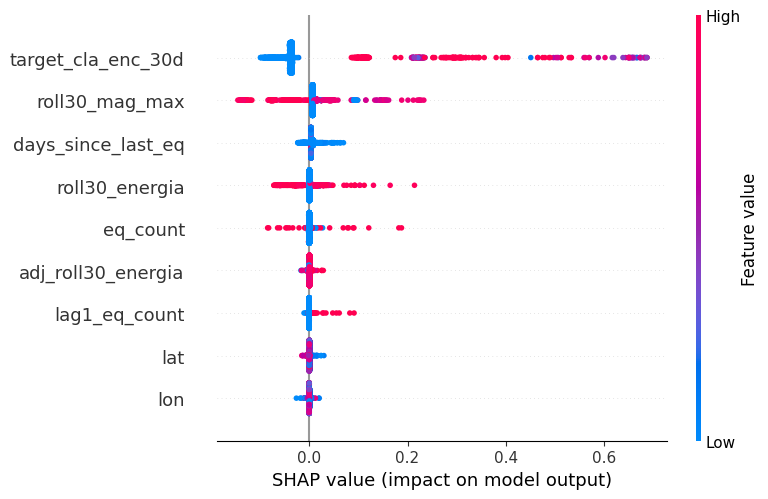

In [13]:
shap_values_positive = shap_values_clf[:, :, 1]
shap.summary_plot(
    shap_values_positive,
    X_shap_clf
)

In [15]:
importance_clf = pd.Series(
    rf_sas_config.feature_importances_,
    index=X_test.columns
).sort_values(ascending=False)

print(importance_clf)

target_cla_enc_30d    0.606436
roll30_mag_max        0.192969
roll30_energia        0.106336
days_since_last_eq    0.043323
eq_count              0.026179
adj_roll30_energia    0.007448
lag1_eq_count         0.007335
lat                   0.005258
lon                   0.004716
dtype: float64


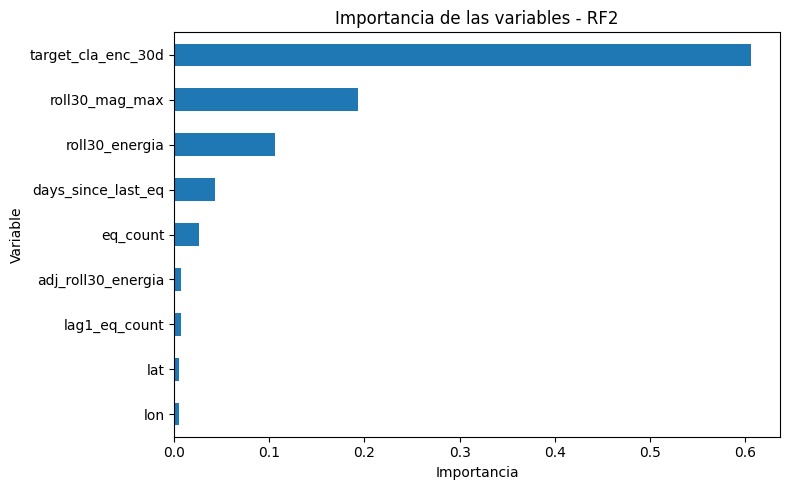

In [16]:
plt.figure(figsize=(8, 5))

importance_clf.sort_values().plot(kind="barh")

plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.title("Importancia de las variables - RF2")

plt.tight_layout()
plt.show()

=== Reporte de Clasificación ===
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    185490
           1       0.54      0.86      0.66      5505

    accuracy                           0.97    190995
   macro avg       0.77      0.92      0.83    190995
weighted avg       0.98      0.97      0.98    190995


=== Importancia de Características ===
              feature  importance
0  target_cla_enc_30d    0.963897
4      roll30_mag_max    0.018032
1  days_since_last_eq    0.014063
3      roll30_energia    0.004008
2  adj_roll30_energia    0.000000
5                 lon    0.000000
6            eq_count    0.000000
7                 lat    0.000000
8       lag1_eq_count    0.000000

=== Matriz de Confusión ===
[[181445   4045]
 [   761   4744]]


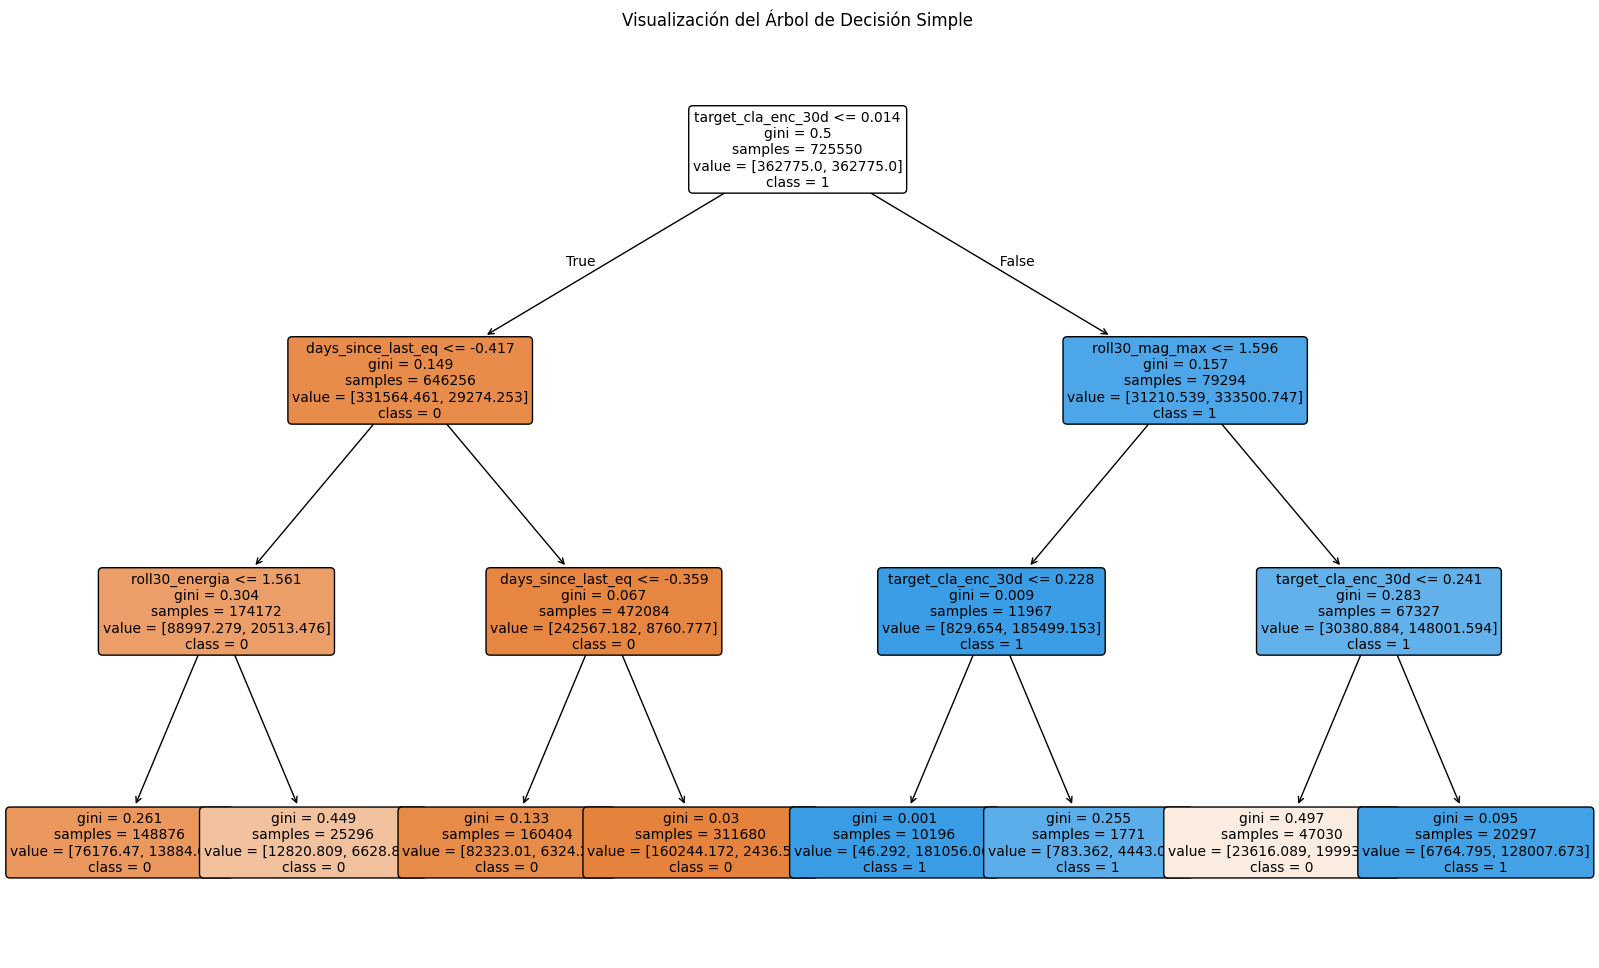

In [18]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

dt_visual_config = DecisionTreeClassifier(
    # === OPCIONES DE ÁRBOL ===
    random_state=12345,         # Semilla para reproducibilidad
    class_weight='balanced',
    # === OPCIONES DE REGLA/DIVISIÓN ===
    max_depth=3,                # Profundidad máxima (reducida a 3 para una visualización clara)
    max_features=None,          # Usar todas las variables para el árbol simple
    min_samples_split=2,        # Tamaño mínimo del nodo para dividir
    
    # === OPCIONES DE NODO ===
    min_samples_leaf=1,         # Tamaño mínimo del nodo hijo
    min_impurity_decrease=1e-5, # Porcentaje más del 1.0E-5 (usando el valor exacto)
    
    # === OTRAS OPCIONES ===
    criterion='gini'            # Medida de impurity (Gini)
)

dt_visual_config.fit(X_train, y_train)

# Evaluar
y_pred = dt_visual_config.predict(X_test)
print("=== Reporte de Clasificación ===")
print(classification_report(y_test, y_pred))

# Importancia de características
importances = pd.DataFrame({
    'feature': listconti2,
    'importance': dt_visual_config.feature_importances_
}).sort_values('importance', ascending=False)
print("\n=== Importancia de Características ===")
print(importances)

print("\n=== Matriz de Confusión ===")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# === VISUALIZACIÓN DEL ÁRBOL ===
plt.figure(figsize=(20, 12))    # Ajustar tamaño según la cantidad de nodos
plot_tree(
    dt_visual_config, 
    feature_names=listconti2,                       # Nombres de las variables
    class_names=[str(c) for c in dt_visual_config.classes_], # Nombres de las clases objetivo
    filled=True,                                    # Colorear nodos según la clase mayoritaria
    rounded=True,                                   # Bordes redondeados en las cajas
    fontsize=10                                     # Tamaño de letra
)
plt.title("Visualización del Árbol de Decisión Simple")
plt.show()

In [11]:
cm_df = pd.DataFrame(
    cm,
    index=['Real: Negativo (Clase 0)', 'Real: Positivo (Clase 1)'],
    columns=['Pred: Negativo (Clase 0)', 'Pred: Positivo (Clase 1)']
)

print("\n📊 MATRIZ DE CONFUSIÓN:")
print(cm_df)
print("\n" + "="*70)

# Extraer valores
tn, fp, fn, tp = cm.ravel()

print(f"""
🔍 LECTURA DETALLADA:

┌──────────────┬─────────────────┬─────────────────┐
│              │ PREDICHO NEGATIVO │ PREDICHO POSITIVO │
├──────────────┼─────────────────┼─────────────────┤
│ REAL NEGATIVO│  {tn} (TN) ✅      │  {fp} (FP) ❌      │
│              │  Correctos       │  Error Tipo I    │
├──────────────┼─────────────────┼─────────────────┤
│ REAL POSITIVO│  {fn} (FN) ❌      │  {tp} (TP) ✅      │
│              │  Error Tipo II   │  Correctos       │
└──────────────┴─────────────────┴─────────────────┘

📌 SIGNIFICADO:
• TN ({tn}): El modelo predijo CORRECTAMENTE "Negativo" cuando era Negativo
• FP ({fp}): El modelo predijo INCORRECTAMENTE "Positivo" cuando era Negativo
• FN ({fn}): El modelo predijo INCORRECTAMENTE "Negativo" cuando era Positivo  
• TP ({tp}): El modelo predijo CORRECTAMENTE "Positivo" cuando era Positivo
""")


📊 MATRIZ DE CONFUSIÓN:
                          Pred: Negativo (Clase 0)  Pred: Positivo (Clase 1)
Real: Negativo (Clase 0)                    185367                       123
Real: Positivo (Clase 1)                      2126                      3379


🔍 LECTURA DETALLADA:

┌──────────────┬─────────────────┬─────────────────┐
│              │ PREDICHO NEGATIVO │ PREDICHO POSITIVO │
├──────────────┼─────────────────┼─────────────────┤
│ REAL NEGATIVO│  185367 (TN) ✅      │  123 (FP) ❌      │
│              │  Correctos       │  Error Tipo I    │
├──────────────┼─────────────────┼─────────────────┤
│ REAL POSITIVO│  2126 (FN) ❌      │  3379 (TP) ✅      │
│              │  Error Tipo II   │  Correctos       │
└──────────────┴─────────────────┴─────────────────┘

📌 SIGNIFICADO:
• TN (185367): El modelo predijo CORRECTAMENTE "Negativo" cuando era Negativo
• FP (123): El modelo predijo INCORRECTAMENTE "Positivo" cuando era Negativo
• FN (2126): El modelo predijo INCORRECTAMENTE "Negativo

In [12]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, f1_score

# Definir el scorer F1
f1_scorer = make_scorer(f1_score, average='binary')

# Pipeline
pipeline = Pipeline([
    ('knn', KNeighborsClassifier())
])

# Parámetros a tunear (NO usar k muy grandes para evitar leakage)
param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9],  # limitar para datos temporales
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

# TimeSeriesSplit en lugar de KFold
tscv = TimeSeriesSplit(n_splits=5)

# GridSearch con validación temporal
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=tscv,  # ¡Usar TimeSeriesSplit!
    scoring=f1_scorer,
    n_jobs=-1,
    verbose=1
)

# IMPORTANTE: Usar todos los datos ordenados temporalmente
grid_search.fit(X_train, y_train) # X_scaled ya ordenado

print(f"✅ Mejores parámetros: {grid_search.best_params_}")
print(f"📊 Mejor score (TimeSeriesCV): {grid_search.best_score_:.4f}")

# Evaluar en datos más recientes (hold-out final)
best_knn = grid_search.best_estimator_

Fitting 5 folds for each of 16 candidates, totalling 80 fits
✅ Mejores parámetros: {'knn__metric': 'manhattan', 'knn__n_neighbors': 3, 'knn__weights': 'uniform'}
📊 Mejor score (TimeSeriesCV): 0.4330


In [14]:
from sklearn.neighbors import KNeighborsClassifier
best_params = {
    'n_neighbors': 3,      # Ejemplo - ajusta según tu tuneo
    'weights': 'uniform',  # o 'distance'
    'metric': 'manhattan'   # o 'euclidean'
}

# ============================================
# ENTRENAR MODELO FINAL
# ============================================
knn_final = KNeighborsClassifier(**best_params)
knn_final.fit(X_train, y_train)

# ============================================
# PREDICCIONES EN TEST
# ============================================
y_pred = knn_final.predict(X_test)
y_pred_proba = knn_final.predict_proba(X_test)
print(classification_report(y_test, y_pred))
from sklearn.metrics import roc_auc_score

# usar probabilidad de la clase positiva (índice 1) para AUC en problema binario
auc = roc_auc_score(y_test, y_pred_proba[:, 1])
print(f"📊 AUC: {auc:.4f}")


              precision    recall  f1-score   support

           0       0.98      0.99      0.99    185490
           1       0.64      0.40      0.50      5505

    accuracy                           0.98    190995
   macro avg       0.81      0.70      0.74    190995
weighted avg       0.97      0.98      0.97    190995

📊 AUC: 0.7664


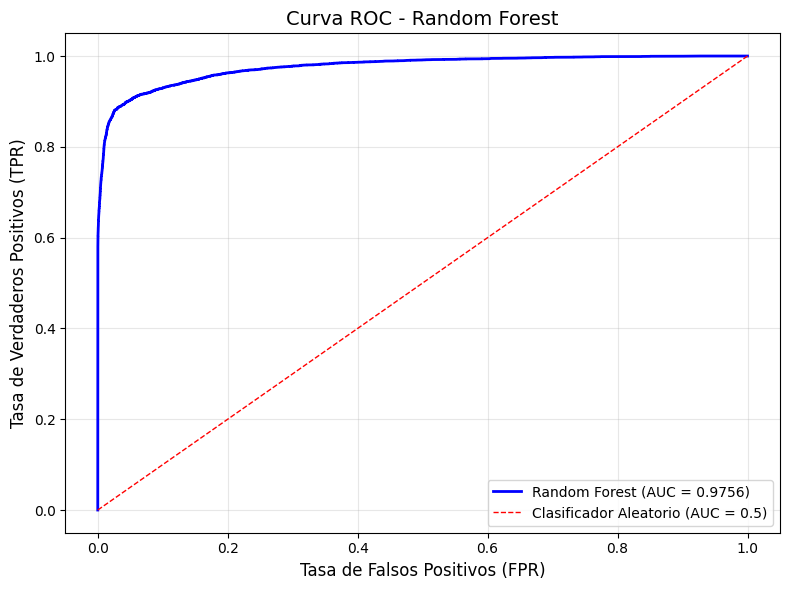


📊 AUC = 0.9756
📈 Interpretación:
   Excelente - Modelo muy discriminativo


In [15]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

def calcular_auc_y_curva(modelo, X_test, y_test, nombre_modelo="Modelo"):
    """
    Calcula AUC y genera curva ROC
    """
    # Obtener probabilidades
    y_pred_proba = modelo.predict_proba(X_test)[:, 1]
    
    # Calcular AUC
    auc = roc_auc_score(y_test, y_pred_proba)
    
    # Calcular curva ROC
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    
    # Visualizar
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, 'b-', linewidth=2, label=f'{nombre_modelo} (AUC = {auc:.4f})')
    plt.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Clasificador Aleatorio (AUC = 0.5)')
    plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
    plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
    plt.title(f'Curva ROC - {nombre_modelo}', fontsize=14)
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"\n📊 AUC = {auc:.4f}")
    print(f"📈 Interpretación:")
    if auc >= 0.9:
        print("   Excelente - Modelo muy discriminativo")
    elif auc >= 0.8:
        print("   Bueno - Modelo con buena capacidad predictiva")
    elif auc >= 0.7:
        print("   Aceptable - Modelo razonable")
    elif auc >= 0.6:
        print("   Regular - Mejorable")
    else:
        print("   Pobre - Modelo no discriminativo")
    
    return auc, fpr, tpr

# Usar con tu Random Forest
auc_rf, fpr_rf, tpr_rf = calcular_auc_y_curva(best_rf, X_test, y_test, "Random Forest")

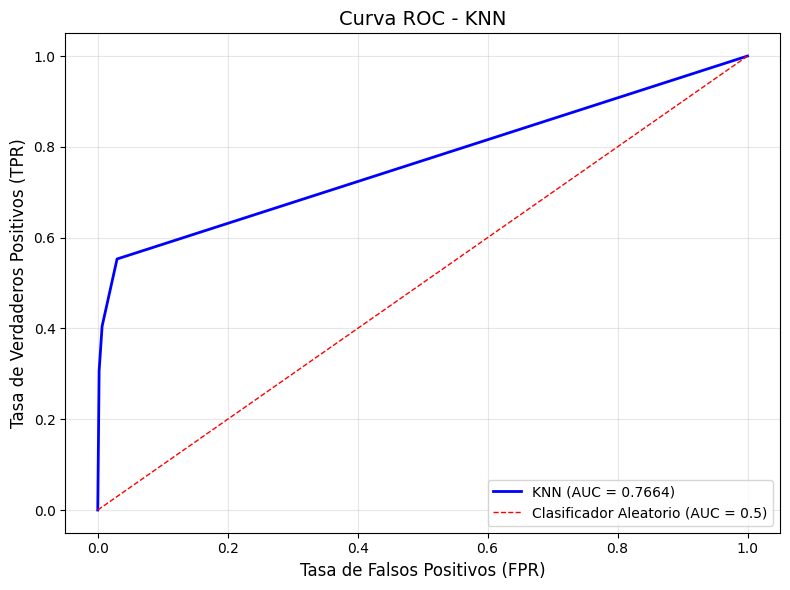


📊 AUC = 0.7664
📈 Interpretación:
   Aceptable - Modelo razonable


In [17]:
auc_rf, fpr_rf, tpr_rf = calcular_auc_y_curva(knn_final, X_test, y_test, "KNN")

In [14]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[184249   1241]
 [  3276   2229]]


In [10]:
def interpret_confusion_matrix(cm):
    cm_df = pd.DataFrame(
        cm,
        index=['Real: Negativo (Clase 0)', 'Real: Positivo (Clase 1)'],
        columns=['Pred: Negativo (Clase 0)', 'Pred: Positivo (Clase 1)']
    )

    print("\n📊 MATRIZ DE CONFUSIÓN:")
    print(cm_df)
    print("\n" + "="*70)

    # Extraer valores
    tn, fp, fn, tp = cm.ravel()

    print(f"""
    🔍 LECTURA DETALLADA:

    ┌──────────────┬─────────────────┬─────────────────┐
    │              │ PREDICHO NEGATIVO │ PREDICHO POSITIVO │
    ├──────────────┼─────────────────┼─────────────────┤
    │ REAL NEGATIVO│  {tn} (TN) ✅      │  {fp} (FP) ❌      │
    │              │  Correctos       │  Error Tipo I    │
    ├──────────────┼─────────────────┼─────────────────┤
    │ REAL POSITIVO│  {fn} (FN) ❌      │  {tp} (TP) ✅      │
    │              │  Error Tipo II   │  Correctos       │
    └──────────────┴─────────────────┴─────────────────┘

    📌 SIGNIFICADO:
    • TN ({tn}): El modelo predijo CORRECTAMENTE "Negativo" cuando era Negativo
    • FP ({fp}): El modelo predijo INCORRECTAMENTE "Positivo" cuando era Negativo
    • FN ({fn}): El modelo predijo INCORRECTAMENTE "Negativo" cuando era Positivo  
    • TP ({tp}): El modelo predijo CORRECTAMENTE "Positivo" cuando era Positivo
    """)

In [16]:
interpret_confusion_matrix(cm)


📊 MATRIZ DE CONFUSIÓN:
                          Pred: Negativo (Clase 0)  Pred: Positivo (Clase 1)
Real: Negativo (Clase 0)                    184249                      1241
Real: Positivo (Clase 1)                      3276                      2229


    🔍 LECTURA DETALLADA:

    ┌──────────────┬─────────────────┬─────────────────┐
    │              │ PREDICHO NEGATIVO │ PREDICHO POSITIVO │
    ├──────────────┼─────────────────┼─────────────────┤
    │ REAL NEGATIVO│  184249 (TN) ✅      │  1241 (FP) ❌      │
    │              │  Correctos       │  Error Tipo I    │
    ├──────────────┼─────────────────┼─────────────────┤
    │ REAL POSITIVO│  3276 (FN) ❌      │  2229 (TP) ✅      │
    │              │  Error Tipo II   │  Correctos       │
    └──────────────┴─────────────────┴─────────────────┘

    📌 SIGNIFICADO:
    • TN (184249): El modelo predijo CORRECTAMENTE "Negativo" cuando era Negativo
    • FP (1241): El modelo predijo INCORRECTAMENTE "Positivo" cuando era Negativo
  

In [17]:
# Para controlar el equilibrio entre precisión y recall
from sklearn.metrics import f1_score, precision_score, recall_score

# Probar diferentes umbrales de decisión
umbrales = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

print("\n🎯 AJUSTE DE UMBRAL PARA CLASE POSITIVA:")
print("="*60)

for umbral in umbrales:
    # Usar probabilidad de clase 1 (positiva)
    y_pred_umbral = (y_pred_proba[:, 1] >= umbral).astype(int)
    
    f1 = f1_score(y_test, y_pred_umbral, average='binary')
    precision = precision_score(y_test, y_pred_umbral, average='binary')
    recall = recall_score(y_test, y_pred_umbral, average='binary')
    
    print(f"Umbral {umbral}: F1={f1:.4f}, Precision={precision:.4f}, Recall={recall:.4f}")

# Elegir mejor umbral según F1
best_umbral = None
best_f1 = 0
for umbral in umbrales:
    y_pred_umbral = (y_pred_proba[:, 1] >= umbral).astype(int)
    f1 = f1_score(y_test, y_pred_umbral, average='binary')
    if f1 > best_f1:
        best_f1 = f1
        best_umbral = umbral

print(f"\n✅ Mejor umbral: {best_umbral} (F1={best_f1:.4f})")

# Usar mejor umbral para predicciones finales
y_pred_optimizado = (y_pred_proba[:, 1] >= best_umbral).astype(int)


🎯 AJUSTE DE UMBRAL PARA CLASE POSITIVA:
Umbral 0.3: F1=0.4330, Precision=0.3559, Recall=0.5530
Umbral 0.4: F1=0.4967, Precision=0.6424, Recall=0.4049
Umbral 0.5: F1=0.4967, Precision=0.6424, Recall=0.4049
Umbral 0.6: F1=0.4967, Precision=0.6424, Recall=0.4049
Umbral 0.7: F1=0.4451, Precision=0.8126, Recall=0.3064
Umbral 0.8: F1=0.4451, Precision=0.8126, Recall=0.3064

✅ Mejor umbral: 0.4 (F1=0.4967)


In [21]:
y_pred_proba_pos = y_pred_proba[:, 1]
print(y_pred_proba_pos)

[0. 0. 0. ... 0. 0. 0.]


In [29]:
percentil_97_pred = np.percentile(y_pred_proba, 97)

# Clasificar: 1 si está en el top 3% de probabilidades, 0 si no
y_pred_top3 = (y_pred_proba_pos >= percentil_97_pred).astype(int)

In [30]:
cm_top3 = confusion_matrix(y_test, y_pred_top3)
interpret_confusion_matrix(cm_top3)


📊 MATRIZ DE CONFUSIÓN:
                          Pred: Negativo (Clase 0)  Pred: Positivo (Clase 1)
Real: Negativo (Clase 0)                    185101                       389
Real: Positivo (Clase 1)                      3818                      1687


    🔍 LECTURA DETALLADA:

    ┌──────────────┬─────────────────┬─────────────────┐
    │              │ PREDICHO NEGATIVO │ PREDICHO POSITIVO │
    ├──────────────┼─────────────────┼─────────────────┤
    │ REAL NEGATIVO│  185101 (TN) ✅      │  389 (FP) ❌      │
    │              │  Correctos       │  Error Tipo I    │
    ├──────────────┼─────────────────┼─────────────────┤
    │ REAL POSITIVO│  3818 (FN) ❌      │  1687 (TP) ✅      │
    │              │  Error Tipo II   │  Correctos       │
    └──────────────┴─────────────────┴─────────────────┘

    📌 SIGNIFICADO:
    • TN (185101): El modelo predijo CORRECTAMENTE "Negativo" cuando era Negativo
    • FP (389): El modelo predijo INCORRECTAMENTE "Positivo" cuando era Negativo
    

In [31]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import make_scorer, f1_score

# TimeSeriesSplit para datos temporales
tscv = TimeSeriesSplit(n_splits=5)

# Definir grid de parámetros
param_grid = {
    'max_depth': [3, 5, 7, 10, 15],
    'min_samples_split': [5, 10, 20, 50],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy'],
    'class_weight': [None, 'balanced']
}

# Crear scorer de F1
f1_scorer = make_scorer(f1_score, average='binary')

# GridSearch con validación temporal
grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=tscv,  # Validación temporal
    scoring=f1_scorer,
    n_jobs=-1,
    verbose=1
)

# Entrenar
print("🔍 Tunando Árbol de Decisión con TimeSeriesSplit...")
grid_search.fit(X_train, y_train)

print(f"\n✅ Mejores parámetros: {grid_search.best_params_}")
print(f"📊 Mejor F1-Score (validación): {grid_search.best_score_:.4f}")

# Evaluar en test
best_tree = grid_search.best_estimator_
y_pred = best_tree.predict(X_test)
f1_test = f1_score(y_test, y_pred, average='binary')

print(f"📈 F1-Score en test: {f1_test:.4f}")

🔍 Tunando Árbol de Decisión con TimeSeriesSplit...
Fitting 5 folds for each of 320 candidates, totalling 1600 fits

✅ Mejores parámetros: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 15, 'min_samples_leaf': 10, 'min_samples_split': 50}
📊 Mejor F1-Score (validación): 0.7553
📈 F1-Score en test: 0.7420


Tuneo RF

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# 1. Lectura de datos
datos = pd.read_csv("datos_mw_conv_final_ohe.csv")
df = datos.copy() # as.data.frame no es estrictamente necesario, pandas ya usa DataFrames

# 2. Suavizar con logaritmo la energía
# np.log1p(x) es el equivalente exacto y optimizado matemáticamente para log(x + 1)
cols_log = [
    'energia_acumulada_diaria', 'energia_lag1', 
    'roll7_energia', 'roll30_energia', 'adj_roll30_energia'
]
df[cols_log] = np.log1p(df[cols_log])

# 3. Estandarización de las variables numéricas
listconti = [
    "eq_count", "energia_acumulada_diaria", "main_mag", "main_depth", "main_lat", 
    "main_lon", "magError", "depthError", "horizontalError", "nst", "gap", "dmin", 
    "rms", "magNst", "is_converted_mag", "lat_bin", "lon_bin", "b_value_daily", 
    "lag1_mag_max", "lag1_eq_count", "energia_lag1", "roll7_eq_count", "roll30_eq_count", 
    "roll7_mag_max", "roll30_mag_max", "roll7_energia", "roll30_energia", 
    "days_since_last_eq", "TARGET_mag_max_next_7d", "lat", "lon", "adj_num_eqs_x", 
    "adj_max_mag_x", "adj_num_eqs_y", "adj_max_mag_y", "adj_roll7_eq_count", 
    "adj_roll7_mag_max", "adj_roll30_energia", "adj_roll30_eq_count", "adj_roll30_mag_max"
]

scaler = StandardScaler()
df[listconti] = scaler.fit_transform(df[listconti])

# 4. Convertir lógicas a numéricas
bool_cols = df.select_dtypes(include=['bool']).columns
df[bool_cols] = df[bool_cols].astype(int)


# Asegurar que la columna 'date' es de tipo datetime para permitir cortes temporales
df['date'] = pd.to_datetime(df['date'])
print(df['date'].dtype)

# 5. División en train y test por corte de tiempo
train = df[df['date'] < "2019-01-01"].copy()
test  = df[df['date'] >= "2019-01-01"].copy()

tuneo = df[(df['date'] < "2019-01-01") & (df['date'] >= "2018-01-01")].copy()


# 6. Target encoding con ventana móvil
# Creamos una función para evitar repetir el código 4 veces.
def apply_rolling_target_encoding(data, target_col, new_col_name):
    """
    Replica el comportamiento de slide_index_dbl(..., .before=days(30), .after=-1)
    """
    # Guardar la media global para el llenado de NAs
    global_mean = data[target_col].mean()
    
    # 1. Ordenar explícitamente es necesario para funciones rolling indexadas
    data = data.sort_values(by=['cell_id', 'date'])
    
    # 2. Configurar la fecha como índice temporal para que funcione el '30D'
    data_idx = data.set_index('date')
    
    # 3. Agrupar y aplicar la ventana móvil.
    # closed='left' es la clave: calcula usando datos hasta el día de ayer, excluyendo hoy (-1)
    rolling_means = (
        data_idx.groupby('cell_id')[target_col]
        .rolling('30D', closed='left')
        .mean()
    )
    
    # 4. Extraer los valores calculados a la columna nueva
    data[new_col_name] = rolling_means.values
    
    # 5. Rellenar NAs iniciales con la media global
    data[new_col_name] = data[new_col_name].fillna(global_mean)
    
    return data

# Aplicación en los conjuntos
# Nota: En tu script de R creabas dataframes paralelos (train_enc_cla, train_enc_cla2). 
# Aquí los agrego al mismo dataframe (train y test) porque es más seguro evitar bifurcar 
# los datos con variables separadas, manteniendo todo consolidado.

# Entrenamiento
train = apply_rolling_target_encoding(train, 'TARGET_occurrence_M3.0', 'target_cla_enc_30d')
train = apply_rolling_target_encoding(train, 'TARGET_occurrence_M4.5', 'target_cla_enc_30d2')
tuneo = apply_rolling_target_encoding(tuneo, 'TARGET_occurrence_M3.0', 'target_cla_enc_30d')

# Prueba
test = apply_rolling_target_encoding(test, 'TARGET_occurrence_M3.0', 'target_cla_enc_30d')
test = apply_rolling_target_encoding(test, 'TARGET_occurrence_M4.5', 'target_cla_enc_30d2')

datetime64[ns]


In [4]:
# Preparar datos
X_train = train[listconti2]
y_train = train["TARGET_occurrence_M3.0"]  # o TARGET_occurrence_M4.5 según el objetivo

X_test = test[listconti2]
y_test = test["TARGET_occurrence_M3.0"]  

X_tuneo = tuneo[listconti2]
y_tuneo = tuneo["TARGET_occurrence_M3.0"]

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import make_scorer, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import classification_report, confusion_matrix
# TimeSeriesSplit para datos temporales
tscv = TimeSeriesSplit(n_splits=5)

# Grid de parámetros (reducido para tiempo de ejecución)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, 20],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [1,2, 5],
    'max_features': [2,3,4,5,6],
    'class_weight': [None, 'balanced']
}

# Crear scorer de F1
f1_scorer = make_scorer(f1_score, average='binary')

# GridSearch con validación temporal
print("🔍 Tunando Random Forest con TimeSeriesSplit...")
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv=tscv,
    scoring=f1_scorer,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_tuneo, y_tuneo)

print(f"\n✅ Mejores parámetros: {grid_search.best_params_}")
print(f"📊 Mejor F1-Score (validación): {grid_search.best_score_:.4f}")

# Evaluar en test
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)
f1_test = f1_score(y_test, y_pred, average='binary')

print(f"📈 F1-Score en test: {f1_test:.4f}")
print(f"\nClassification Report en test:")
print(classification_report(y_test, y_pred))

🔍 Tunando Random Forest con TimeSeriesSplit...
Fitting 5 folds for each of 540 candidates, totalling 2700 fits

✅ Mejores parámetros: {'class_weight': None, 'max_depth': 10, 'max_features': 6, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
📊 Mejor F1-Score (validación): 0.8394
📈 F1-Score en test: 0.6816

Classification Report en test:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    185490
           1       0.88      0.56      0.68      5505

    accuracy                           0.99    190995
   macro avg       0.93      0.78      0.84    190995
weighted avg       0.98      0.99      0.98    190995



In [7]:
param_grid = {
    'n_estimators': [100],
    'max_depth': [10],
    'min_samples_split': [5],
    'min_samples_leaf': [1],
    'max_features': [6],
    'class_weight': [None]
}

print("🔍 Tunando Random Forest con TimeSeriesSplit...")
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv=tscv,
    scoring=f1_scorer,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print(f"\n✅ Mejores parámetros: {grid_search.best_params_}")
print(f"📊 Mejor F1-Score (validación): {grid_search.best_score_:.4f}")

# Evaluar en test
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)
f1_test = f1_score(y_test, y_pred, average='binary')

print(f"📈 F1-Score en test: {f1_test:.4f}")
print(f"\nClassification Report en test:")
print(classification_report(y_test, y_pred))

🔍 Tunando Random Forest con TimeSeriesSplit...
Fitting 5 folds for each of 1 candidates, totalling 5 fits

✅ Mejores parámetros: {'class_weight': None, 'max_depth': 10, 'max_features': 6, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
📊 Mejor F1-Score (validación): 0.7594
📈 F1-Score en test: 0.7514

Classification Report en test:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    185490
           1       0.97      0.61      0.75      5505

    accuracy                           0.99    190995
   macro avg       0.98      0.81      0.87    190995
weighted avg       0.99      0.99      0.99    190995



In [8]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[185374    116]
 [  2122   3383]]


In [11]:
interpret_confusion_matrix(cm)


📊 MATRIZ DE CONFUSIÓN:
                          Pred: Negativo (Clase 0)  Pred: Positivo (Clase 1)
Real: Negativo (Clase 0)                    185374                       116
Real: Positivo (Clase 1)                      2122                      3383


    🔍 LECTURA DETALLADA:

    ┌──────────────┬─────────────────┬─────────────────┐
    │              │ PREDICHO NEGATIVO │ PREDICHO POSITIVO │
    ├──────────────┼─────────────────┼─────────────────┤
    │ REAL NEGATIVO│  185374 (TN) ✅      │  116 (FP) ❌      │
    │              │  Correctos       │  Error Tipo I    │
    ├──────────────┼─────────────────┼─────────────────┤
    │ REAL POSITIVO│  2122 (FN) ❌      │  3383 (TP) ✅      │
    │              │  Error Tipo II   │  Correctos       │
    └──────────────┴─────────────────┴─────────────────┘

    📌 SIGNIFICADO:
    • TN (185374): El modelo predijo CORRECTAMENTE "Negativo" cuando era Negativo
    • FP (116): El modelo predijo INCORRECTAMENTE "Positivo" cuando era Negativo
    

In [19]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   - -------------------------------------- 2.6/101.7 MB 25.1 MB/s eta 0:00:04
   --- ------------------------------------ 9.4/101.7 MB 30.9 MB/s eta 0:00:03
   ------ --------------------------------- 17.0/101.7 MB 33.6 MB/s eta 0:00:03
   ---------- ----------------------------- 26.2/101.7 MB 36.9 MB/s eta 0:00:03
   ------------- -------------------------- 35.1/101.7 MB 38.4 MB/s eta 0:00:02
   ----------------- ---------------------- 44.6/101.7 MB 38.8 MB/s eta 0:00:02
   -------------------- ------------------- 53.2/101.7 MB 39.4 MB/s eta 0:00:02
   ------------------------ --------------- 62.4/101.7 MB 39.7 MB/s eta 0:00:01
   ---------------------------- ----------- 71.6/101.7 MB 40.4 MB/s eta 0:00:01
   ------------------------------- -------- 80.0/101.7 MB 40.5 MB/s eta 0:00:01
   ---------------------------------- ----- 88.9/101.


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\longj\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [20]:
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, roc_auc_score, classification_report
from sklearn.model_selection import TimeSeriesSplit
import pandas as pd
import numpy as np

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import make_scorer, f1_score

# TimeSeriesSplit para datos temporales
tscv = TimeSeriesSplit(n_splits=5)

# Grid reducido para tiempo de ejecución
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'n_estimators': [100, 200],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'scale_pos_weight': [1, 3, 5],  # Importante para clase desbalanceada
    'reg_alpha': [0, 0.1],
    'reg_lambda': [0, 1.0]
}

# Crear scorer de F1
f1_scorer = make_scorer(f1_score, average='binary')

print("🔍 Tunando XGBoost con TimeSeriesSplit...")
print(f"Total combinaciones: {np.prod([len(v) for v in param_grid.values()])}")

grid_search = GridSearchCV(
    XGBClassifier(
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss',
        verbosity=0
    ),
    param_grid,
    cv=tscv,
    scoring=f1_scorer,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_tuneo, y_tuneo)

print(f"\n✅ Mejores parámetros: {grid_search.best_params_}")
print(f"📊 Mejor F1-Score (validación): {grid_search.best_score_:.4f}")


🔍 Tunando XGBoost con TimeSeriesSplit...
Total combinaciones: 864
Fitting 5 folds for each of 864 candidates, totalling 4320 fits

✅ Mejores parámetros: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'scale_pos_weight': 1, 'subsample': 1.0}
📊 Mejor F1-Score (validación): 0.8376


In [22]:
param_grid = {
    'max_depth': [ 5],
    'learning_rate': [0.05],
    'n_estimators': [100],
    'subsample': [ 1.0],
    'colsample_bytree': [1.0],
    'scale_pos_weight': [1],  # Importante para clase desbalanceada
    'reg_alpha': [ 0.1],
    'reg_lambda': [1.0]
}
print("🔍 Tunando XGBoost con TimeSeriesSplit...")
grid_search = GridSearchCV(
    XGBClassifier(
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss',
        verbosity=0
    ),
    param_grid,
    cv=tscv,
    scoring=f1_scorer,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print(f"\n✅ Mejores parámetros: {grid_search.best_params_}")
print(f"📊 Mejor F1-Score (validación): {grid_search.best_score_:.4f}")

# Evaluar en test
best_xgb = grid_search.best_estimator_
y_pred = best_xgb.predict(X_test)
f1_test = f1_score(y_test, y_pred, average='binary')

print(f"📈 F1-Score en test: {f1_test:.4f}")
print(f"\nClassification Report en test:")
print(classification_report(y_test, y_pred))

🔍 Tunando XGBoost con TimeSeriesSplit...
Fitting 5 folds for each of 1 candidates, totalling 5 fits

✅ Mejores parámetros: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'scale_pos_weight': 1, 'subsample': 1.0}
📊 Mejor F1-Score (validación): 0.7564
📈 F1-Score en test: 0.7478

Classification Report en test:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    185490
           1       0.97      0.61      0.75      5505

    accuracy                           0.99    190995
   macro avg       0.98      0.80      0.87    190995
weighted avg       0.99      0.99      0.99    190995

